In [ ]:
import numpy as np
A=np.array([[1,1,1],[1,-2,0],[0,-1,1]])
b=np.array([100,0,10])
Solution=np.linalg.solve(A,b)
Solution_val=np.round(Solution,2)
print(Solution_val)

In [ ]:
from scipy.optimize import fsolve
F=100#Fresh feed molar flow rate in mol/min
def Recycle_stream(variables):
    R,Fin,X=variables
    A=F-Fin+R
    B=(1-X)*Fin-R
    C=(0.5/(0.5+Fin/F))-X
    return [A,B,C]
solution=fsolve(Recycle_stream,[80,0.8,180])
print(Recycle_stream([80,0.8,180]))     
    

In [ ]:
from scipy.integrate import odeint 
import numpy as np
def diff_eq(y,x):
    return 5-10*y*x
x=np.linspace(0,100,100)
solution=odeint(diff_eq,1,x)
print(solution)

In [ ]:
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
#Bubble point at a Liquid composition
def bubble_point(T):
    P=760
    Psat_B=10**(6.90565-(1211.033/(220.79+T)))
    Psat_T=10**(6.95464-(1344.8/(219.48+T)))
    return Psat_B*xb+Psat_T*xt-P
Bubble_Point=fsolve(bubble_point,100)
print(f'Bubble point is {Bubble_Point[0]:.2f}°C')
T_bp=Bubble_Point
Psat_B=10**(6.90565-(1211.033/(220.79+T_bp)))
Psat_T=10**(6.95464-(1344.8/(219.48+T_bp)))
P=760
yb=xb*Psat_B/P
yt=xt*Psat_T/P
print (f'Vapor composition in bubble is {yb[0]:.2f},{yt[0]:.2f},and sum is {(yt+yb)[0]:.0f} as expected')
#Dew point at a Vapor Composition
yben=0.4
ytou=0.6
def dew_point(T):
    P=760
    Psat_B=10**(6.90565-(1211.033/(220.79+T)))
    Psat_T=10**(6.95464-(1344.8/(219.48+T)))
    return yben*P/Psat_B+ytou*P/Psat_T-1
Ans=fsolve(dew_point,0)
print(f'Dew point is {Ans[0]:.2f}°C')
T_dp=Ans
P=760
Psat_Ben=10**(6.90565-(1211.033/(220.79+T_dp)))
Psat_Tou=10**(6.95464-(1344.8/(219.48+T_dp)))
xben=yben*P/Psat_Ben
xtou=ytou*P/Psat_Tou
print (f'Liquid composititon in dew is {xben[0]:.2f},{xtou[0]:.2f},and sum is {(xben+xtou)[0]:.0f} as expected')
x_benzene = np.linspace(0,1,21)
x_toulene = 1-x_benzene
bubble_T=[]
y_benzene=[]
guess=100
for xb,xt in zip(x_benzene,x_toulene):
    def bubble_point(T):
        P=760
        Psat_B=10**(6.90565-(1211.033/(220.79+T)))
        Psat_T=10**(6.95464-(1344.8/(219.48+T)))
        return Psat_B*xb+Psat_T*xt-P
    Ans=fsolve(bubble_point,guess)
    T_bp = float(Ans[0])
    guess=float(Ans[0])
    Psat_B=10**(6.90565-(1211.033/(220.79+T_bp)))
    Psat_T=10**(6.95464-(1344.8/(219.48+T_bp)))
    P=760
    yb=xb*Psat_B/P
    yt=xt*Psat_T/P
    bubble_T.append(T_bp)
    y_benzene.append(yb)
y_ben=np.linspace(0,1,21)
y_tou=1-y_ben
T_dewpoint=[]
x_benzene2=[]
for yben,ytou in zip(y_ben,y_tou):
    def dew_point(T):
        P=760
        Psat_B=10**(6.90565-(1211.033/(220.79+T)))
        Psat_T=10**(6.95464-(1344.8/(219.48+T)))
        return yben*P/Psat_B+ytou*P/Psat_T-1
    Ans=fsolve(dew_point,guess)
    guess=float(Ans[0])
    T_dp=float(Ans[0])
    P=760
    Psat_Ben=10**(6.90565-(1211.033/(220.79+T_dp)))
    Psat_Tou=10**(6.95464-(1344.8/(219.48+T_dp)))
    xben=yben*P/Psat_Ben
    xtou=ytou*P/Psat_Tou
    T_dewpoint.append(T_dp)
    x_benzene2.append(xben)
plt.plot(x_benzene,bubble_T, label='Bubble point curve')
plt.plot(y_ben,T_dewpoint, label='Dew point curve')
plt.xlabel('Composition of benzene')
plt.ylabel('Temprature(°C)')
plt.legend()
plt.show()
    

In [11]:
#Analysis of single pass shell and tube heat exchanger with inlet tempratures known and heat exchanger area known.
#Given Values
import numpy as np
from scipy.optimize import fsolve
mh=2.5 #in Kg/sec
mc=3
Cp_c=4180 #in J/kgK
Cp_h=4180
Th_in=120 #in °C
Tc_in=25
UA =18000 #in W/K
def HX(outlet_temps):
    Th_out,Tc_out=outlet_temps
    LMTD=((Th_in-Tc_out)-(Th_out-Tc_in))/np.log((Th_in-Tc_out)/(Th_out-Tc_in))
    energy_balance=mh*Cp_h*(Th_in-Th_out)-mc*Cp_c*(Tc_out-Tc_in)
    heat_transfer=UA*LMTD-mh*Cp_h*(Th_in-Th_out)
    return [energy_balance,heat_transfer]
Ans=fsolve(HX,[50,80])
round_ans=np.round(Ans,2)
print(f'Th_out is {round_ans[0]}°C and Tc_out is {round_ans[1]}°C')

    
    

Th_out is 56.72°C and Tc_out is 77.74°C


K1,K2,K3 values are 2.65,0.73,0.34, respectively
Psi value for temprature=100°C is 0.29
Liquid compositions for benzene, toulene and ethylbenzene are 0.2,0.49 and 0.31, respectively
Vapor compositions for benzene, toulene and ethylbenzene are 0.54,0.36 and 0.11, respectively
Liquid flowrate=71Kmol/hr
Vapor flowrate=29.000000Kmol/hr


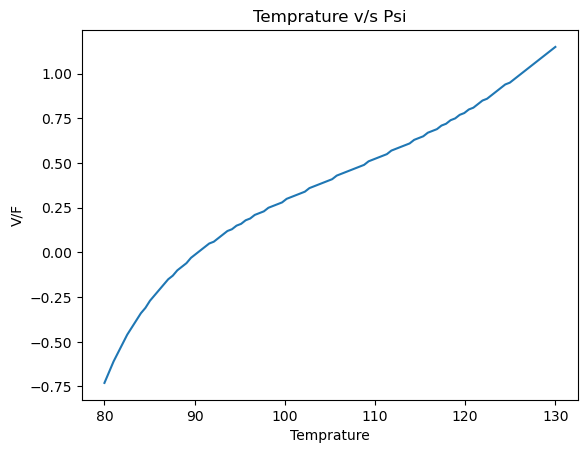

In [28]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
P=1 #in atm
T=100 #in °C
F=100 #in Kmol/h
def Psat(A,B,C):
    return 10**(A-B/(C+T))
K_ben=Psat(4.1814,1203.835,220.373)/P
K_tol=Psat(4.07827,1346.382,219.482)/P
K_eth=Psat(4.07488,1419.315,212.593)/P
print(f'K1,K2,K3 values are {K_ben:.2f},{K_tol:.2f},{K_eth:.2f}, respectively')
z_ben=0.3
z_tol=0.45
z_eth=0.25
Ki=np.array([K_ben,K_tol,K_eth])
zi=np.array([z_ben,z_tol,z_eth])
def rachford(psi):
    return sum(z*(K-1)/(1+psi*(K-1)) for (z,K) in zip(zi,Ki))
Ans=fsolve(rachford,1)
Psi=np.round(Ans[0],2)
print(f'Psi value for temprature={T}°C is {Psi}')
xi=[]
yi=[]
for z,K in zip(zi,Ki):
    x=z/(1+Psi*(K-1))
    xi.append(x)
for K,x in zip(Ki,xi):
    y=K*x
    yi.append(y)
Xi=np.round(xi,2)
Yi=np.round(yi,2)
print(f'Liquid compositions for benzene, toulene and ethylbenzene are {Xi[0]},{Xi[1]} and {Xi[2]}, respectively')
print(f'Vapor compositions for benzene, toulene and ethylbenzene are {Yi[0]},{Yi[1]} and {Yi[2]}, respectively')
L=(1-Psi)*F
V=Psi*F
print(f'Liquid flowrate={L:.0f}Kmol/hr')
print(f'Vapor flowrate={V:0f}Kmol/hr')
Ti=np.linspace(80,130,100)
Psi_t=[]
for T in Ti:
    def Psat(A,B,C):
        return 10**(A-B/(C+T))
    K_ben=Psat(4.1814,1203.835,220.373)/P
    K_tou=Psat(4.07827,1346.382,219.482)/P
    K_eth=Psat(4.07488,1419.315,212.593)/P
    z_ben=0.3
    z_tol=0.45
    z_eth=0.25
    Ki=np.array([K_ben,K_tol,K_eth])
    zi=np.array([z_ben,z_tol,z_eth])
    def rachford(psi):
        return sum(z*(K-1)/(1+psi*(K-1)) for (z,K) in zip(zi,Ki))
    Ans=fsolve(rachford,1)
    Psi=np.round(Ans[0],2)
    Psi_t.append(Psi)
plt.plot(Ti,Psi_t)
plt.ylabel('V/F')
plt.xlabel('Temprature')
plt.title('Temprature v/s Psi')
plt.show()

    
    

    
    
    